# Results and Figures for Manuscript

This notebook generates publication-quality figures comparing GMM and Flow Matching approaches.

**Authors:** Victor Alves and John R. Kitchin

## System Information

This section documents the computational environment used to run this notebook.

In [ ]:
import sys
import platform
import time
import psutil
import os

print("System Information")
print("=" * 70)
print(f"Python version: {sys.version}")
print(f"Platform: {platform.platform()}")
print(f"Processor: {platform.processor()}")
print(f"CPU count: {psutil.cpu_count(logical=False)} physical, {psutil.cpu_count(logical=True)} logical")
print(f"Total memory: {psutil.virtual_memory().total / (1024**3):.2f} GB")
print("=" * 70)

# Key package versions
print("\nKey Library Versions:")
print("-" * 70)
packages = [
    ('numpy', 'np'),
    ('scipy', 'scipy'),
    ('matplotlib', 'matplotlib'),
    ('sklearn', 'sklearn'),
    ('torch', 'torch'),
    ('gmr', 'gmr'),
]

for pkg_name, import_name in packages:
    try:
        mod = __import__(pkg_name)
        version = getattr(mod, '__version__', 'unknown')
        print(f"{pkg_name:<20} {version}")
    except ImportError:
        print(f"{pkg_name:<20} NOT INSTALLED")

print("-" * 70)

# Initialize timing and memory tracking
_start_time = time.time()
_process = psutil.Process(os.getpid())
_start_memory_mb = _process.memory_info().rss / (1024 * 1024)

print(f"\nNotebook execution started: {time.strftime('%Y-%m-%d %H:%M:%S', time.localtime(_start_time))}")
print(f"Initial memory usage: {_start_memory_mb:.2f} MB")
print("=" * 70)

## System Information

This section documents the computational environment used to run this notebook.

## Setup

In [31]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import warnings
import os

# Force CPU
os.environ['JAX_PLATFORMS'] = 'cpu'

import torch

# Import reusable utilities
from generative_optimization import (
    generate_samples,
    best_gmm,
    ConditionalFlowMatching
)

# Figure settings for publication
mpl.rcParams['figure.facecolor'] = 'white'
mpl.rcParams['axes.facecolor'] = 'white'
mpl.rcParams['figure.dpi'] = 150
mpl.rcParams['font.size'] = 11
mpl.rcParams['axes.labelsize'] = 12
mpl.rcParams['axes.titlesize'] = 12
mpl.rcParams['legend.fontsize'] = 10

warnings.filterwarnings('ignore')

# Set seeds
torch.manual_seed(42)
np.random.seed(42)

print("Setup complete")

Setup complete


---
## Peng-Robinson Equation of State: Root Finding

The Peng-Robinson equation of state in compressibility factor form is a cubic equation:

$$Z^3 - (1-B)Z^2 + (A-3B^2-2B)Z - (AB-B^2-B^3) = 0$$

Where:
- $A = \frac{aP}{R^2T^2}$, $B = \frac{bP}{RT}$
- $a = 0.45724 \frac{R^2T_c^2}{P_c} \alpha(T)$, $b = 0.07780 \frac{RT_c}{P_c}$
- $\alpha(T) = [1 + \kappa(1-\sqrt{T/T_c})]^2$
- $\kappa = 0.37464 + 1.54226\omega - 0.26992\omega^2$

We use **propane** as the test substance with critical properties from NIST.

In [32]:
# Peng-Robinson EOS for propane
# Critical properties (NIST)
Tc = 369.83  # K - Critical temperature
Pc = 42.48e5  # Pa (42.48 bar) - Critical pressure
omega = 0.1523  # Acentric factor
R = 8.314  # J/(mol*K) - Gas constant

# PR-EOS parameters
kappa = 0.37464 + 1.54226*omega - 0.26992*omega**2

def pr_eos_coefficients(T, P):
    """Calculate A, B and cubic coefficients for PR-EOS."""
    Tr = T / Tc
    alpha = (1 + kappa * (1 - np.sqrt(Tr)))**2
    
    a = 0.45724 * R**2 * Tc**2 / Pc * alpha
    b = 0.07780 * R * Tc / Pc
    
    A = a * P / (R**2 * T**2)
    B = b * P / (R * T)
    
    # Cubic: Z^3 + c2*Z^2 + c1*Z + c0 = 0
    c2 = -(1 - B)
    c1 = A - 3*B**2 - 2*B
    c0 = -(A*B - B**2 - B**3)
    
    return A, B, [1, c2, c1, c0]

def pr_eos_residual(Z, A, B):
    """Residual of PR-EOS cubic equation (should equal zero at roots)."""
    return Z**3 - (1-B)*Z**2 + (A - 3*B**2 - 2*B)*Z - (A*B - B**2 - B**3)

# Test conditions: T=300 K, P=10 bar (two-phase region for propane)
T_test, P_test = 300, 10e5
A, B, coeffs = pr_eos_coefficients(T_test, P_test)

# Analytical roots
roots_analytical = np.roots(coeffs)
real_roots = np.sort(roots_analytical[np.abs(roots_analytical.imag) < 1e-10].real)

print(f"Propane at T={T_test} K, P={P_test/1e5:.1f} bar")
print(f"A = {A:.6f}, B = {B:.6f}")
print(f"\nAnalytical Z roots:")
print(f"  Z_liquid   = {real_roots[0]:.6f}")
print(f"  Z_unstable = {real_roots[1]:.6f}")
print(f"  Z_vapor    = {real_roots[2]:.6f}")

Propane at T=300 K, P=10.0 bar
A = 0.183771, B = 0.022578

Analytical Z roots:
  Z_liquid   = 0.034783
  Z_unstable = 0.128036
  Z_vapor    = 0.814604


### Train GMM for Root Finding

In [33]:
# Build generative model for root finding
# Sample Z values and compute the cubic residual
# Use 2000 samples for sharper distributions (same as flow matching)
Z_samples = np.linspace(0.01, 0.99, 2000)
residual_samples = pr_eos_residual(Z_samples, A, B)

data_gmm = np.column_stack([Z_samples, residual_samples])

gmm_root, gmm_info = best_gmm(data_gmm, verbose=True)
print(f"\nBest GMM: {gmm_info['best_k']} components")

k=1: BIC=-6390.6 *
k=2: BIC=-13565.9 *
k=3: BIC=-15602.4 *
k=4: BIC=-17827.6 *
k=5: BIC=-19385.1 *
k=6: BIC=-20380.9 *
k=7: BIC=-20871.5 *
k=8: BIC=-21234.8 *
k=9: BIC=-21879.0 *
k=10: BIC=-22039.6 *
k=11: BIC=-22173.3 *
k=12: BIC=-22384.3 *
k=13: BIC=-22420.7 *
k=14: BIC=-22520.8 *
k=15: BIC=-22548.1 *
k=16: BIC=-22569.8 *
k=17: BIC=-22593.7 *
k=18: BIC=-22608.6 *
k=19: BIC=-22602.3
k=20: BIC=-22601.2
k=21: BIC=-22580.4
k=22: BIC=-22575.7
k=23: BIC=-22527.2
k=24: BIC=-22519.1
k=25: BIC=-22481.3
k=26: BIC=-22453.2
k=27: BIC=-22413.9
k=28: BIC=-22380.6
Early stopping at k=28

Best GMM: 18 components


In [34]:
# Find roots by conditioning on residual = 0
c_gmm = gmm_root.condition([1], [[0.0]])
Z_gmm_samples = c_gmm.sample(1000)[:, 0]

print("GMM root finding results (conditioning on residual=0):")
print(f"  Samples: {len(Z_gmm_samples)}")
print(f"  Mean: {Z_gmm_samples.mean():.4f}, Std: {Z_gmm_samples.std():.4f}")

GMM root finding results (conditioning on residual=0):
  Samples: 1000
  Mean: 0.1321, Std: 0.1858


### Train Flow Matching for Root Finding

In [35]:
# Train Flow Matching models
# Uses the same 2000 samples as GMM for fair comparison

# Model 1: Generate Z conditioned on residual (for root finding)
x_data_fm = Z_samples.reshape(-1, 1)  # Z values to generate
c_data_fm = residual_samples.reshape(-1, 1)  # Residual to condition on

fm_root = ConditionalFlowMatching(x_dim=1, c_dim=1, hidden_dim=128, n_layers=4)
fm_history = fm_root.fit(x_data_fm, c_data_fm, epochs=2000, batch_size=128, verbose=True)

# Model 2: Generate residual conditioned on Z (for forward prediction / fitting)
fm_forward = ConditionalFlowMatching(x_dim=1, c_dim=1, hidden_dim=128, n_layers=4)
fm_forward_history = fm_forward.fit(c_data_fm, x_data_fm, epochs=2000, batch_size=128, verbose=True)
print("\nTrained FM forward model (Z -> residual) for visualization")

Training:   0%|          | 0/2000 [00:00<?, ?it/s]

Training:   0%|          | 0/2000 [00:00<?, ?it/s]


Trained FM forward model (Z -> residual) for visualization


In [36]:
# Find roots by conditioning on residual = 0
# Use more integration steps for more accurate sampling
Z_fm_samples = fm_root.sample(c_values=[[0.0]], n_samples=1000, n_steps=200)[:, 0]

print("Flow Matching root finding results (conditioning on residual=0):")
print(f"  Samples: {len(Z_fm_samples)}")
print(f"  Mean: {Z_fm_samples.mean():.4f}, Std: {Z_fm_samples.std():.4f}")

Flow Matching root finding results (conditioning on residual=0):
  Samples: 1000
  Mean: 0.1059, Std: 0.1550


---
## Publication Figure: GMM vs Flow Matching Comparison

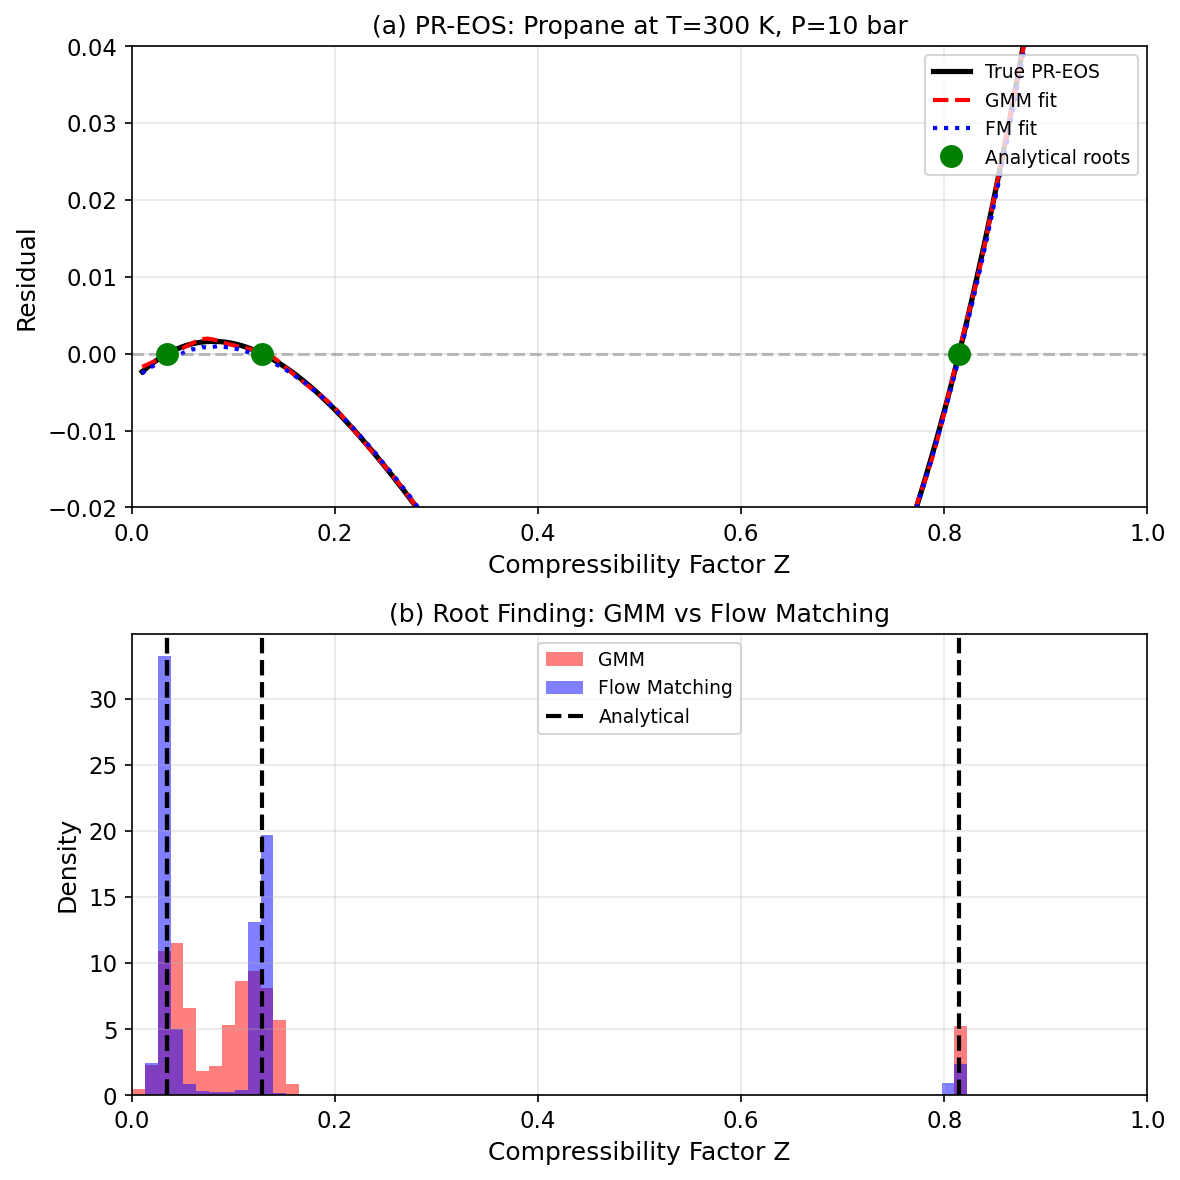


Figure saved as 'preos_comparison.png'


In [37]:
# Create publication figure (2 panels stacked vertically)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 8))

# ============================================================
# Top: PR-EOS cubic polynomial and roots, with GMM and FM fits
# ============================================================
Z_plot = np.linspace(0.01, 0.99, 200)
residual_plot = pr_eos_residual(Z_plot, A, B)

# True PR-EOS cubic
ax1.plot(Z_plot, residual_plot, 'k-', lw=2.5, label='True PR-EOS')

# GMM prediction (forward: Z -> residual)
Z_plot_col = Z_plot.reshape(-1, 1)
residual_gmm_pred = gmm_root.predict([0], Z_plot_col)[:, 0]
ax1.plot(Z_plot, residual_gmm_pred, 'r--', lw=2, label='GMM fit')

# Flow Matching prediction (forward: Z -> residual)
# Use the fm_forward model which was trained to predict residual from Z
residual_fm_pred = fm_forward.predict(Z_plot_col, n_samples=50)
ax1.plot(Z_plot, residual_fm_pred, 'b:', lw=2, label='FM fit')

ax1.axhline(0, color='gray', ls='--', alpha=0.5)
ax1.plot(real_roots, [0, 0, 0], 'go', ms=10, zorder=5, label='Analytical roots')

ax1.set_xlabel('Compressibility Factor Z')
ax1.set_ylabel('Residual')
ax1.set_title(f'(a) PR-EOS: Propane at T={T_test} K, P={P_test/1e5:.0f} bar')
ax1.legend(loc='upper right', fontsize=9)
ax1.grid(True, alpha=0.3)
ax1.set_xlim(0, 1)
ax1.set_ylim(-0.02, 0.04)

# ============================================================
# Bottom: Overlapping histograms for GMM and Flow Matching
# ============================================================
bins = np.linspace(0, 1, 80)

ax2.hist(Z_gmm_samples, bins=bins, alpha=0.5, color='red', 
         label='GMM', density=True)
ax2.hist(Z_fm_samples, bins=bins, alpha=0.5, color='blue', 
         label='Flow Matching', density=True)

for root in real_roots:
    ax2.axvline(root, color='black', ls='--', lw=2)
ax2.axvline(real_roots[0], color='black', ls='--', lw=2, label='Analytical')

ax2.set_xlabel('Compressibility Factor Z')
ax2.set_ylabel('Density')
ax2.set_title('(b) Root Finding: GMM vs Flow Matching')
ax2.legend(loc='upper center', fontsize=9)
ax2.grid(True, alpha=0.3)
ax2.set_xlim(0, 1)

plt.tight_layout()
plt.savefig('preos_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nFigure saved as 'preos_comparison.png'")

### Quantitative Comparison

In [38]:
from generative_optimization import cluster_stats

print("Root Finding Comparison: Propane PR-EOS")
print(f"Conditions: T = {T_test} K, P = {P_test/1e5:.0f} bar")
print("=" * 70)

print(f"\nAnalytical roots:")
print(f"  Z_liquid   = {real_roots[0]:.6f}")
print(f"  Z_unstable = {real_roots[1]:.6f}")
print(f"  Z_vapor    = {real_roots[2]:.6f}")

print(f"\nGMM clusters (conditioned on residual=0):")
cluster_stats(Z_gmm_samples)

print(f"\nFlow Matching clusters (conditioned on residual=0):")
cluster_stats(Z_fm_samples)

# Verify residuals at sampled roots
residual_gmm = pr_eos_residual(Z_gmm_samples, A, B)
residual_fm = pr_eos_residual(Z_fm_samples, A, B)

print(f"\nResidual verification:")
print(f"  GMM:  mean|residual| = {np.mean(np.abs(residual_gmm)):.6f}")
print(f"  FM:   mean|residual| = {np.mean(np.abs(residual_fm)):.6f}")

Root Finding Comparison: Propane PR-EOS
Conditions: T = 300 K, P = 10 bar

Analytical roots:
  Z_liquid   = 0.034783
  Z_unstable = 0.128036
  Z_vapor    = 0.814604

GMM clusters (conditioned on residual=0):
  0:   0.8143 +/- 0.0021 (n=66)
  1:   0.0839 +/- 0.0417 (n=934)

Flow Matching clusters (conditioned on residual=0):
  0:   0.8129 +/- 0.0039 (n=42)
  1:   0.0749 +/- 0.0470 (n=958)

Residual verification:
  GMM:  mean|residual| = 0.000821
  FM:   mean|residual| = 0.000360


### Physical Interpretation

In [39]:
# Compute molar volumes from Z values
def Z_to_V(Z, T, P):
    """Convert compressibility factor to molar volume."""
    return Z * R * T / P

print("Physical interpretation of roots:")
print("=" * 50)
for i, (root, label) in enumerate(zip(real_roots, ['Liquid', 'Unstable', 'Vapor'])):
    V = Z_to_V(root, T_test, P_test)
    rho = 44.1 / (V * 1000)  # kg/m³ (propane MW = 44.1 g/mol)
    print(f"\n{label} phase:")
    print(f"  Z = {root:.6f}")
    print(f"  V = {V*1e6:.2f} cm³/mol")
    print(f"  ρ = {rho:.2f} kg/m³")

Physical interpretation of roots:

Liquid phase:
  Z = 0.034783
  V = 86.76 cm³/mol
  ρ = 508.32 kg/m³

Unstable phase:
  Z = 0.128036
  V = 319.35 cm³/mol
  ρ = 138.09 kg/m³

Vapor phase:
  Z = 0.814604
  V = 2031.78 cm³/mol
  ρ = 21.71 kg/m³


---
## Equality Constrained Optimization: Minimum Distance to Target Blend

A refinery wants to find the blend composition closest to a target recipe while meeting an octane specification. This is a **quadratic programming** problem with an interior solution.

**Objective:** Minimize deviation from target blend $(x_1^*, x_2^*, x_3^*) = (0.4, 0.4, 0.2)$
$$\min_{x_1, x_2, x_3} \quad (x_1 - 0.4)^2 + (x_2 - 0.4)^2 + (x_3 - 0.2)^2$$

**Constraints:**
1. Meet target octane (RON = 87): $95 x_1 + 82 x_2 + 94 x_3 = 87$
2. Mass balance: $x_1 + x_2 + x_3 = 1$

| Component | Target | RON |
|-----------|--------|-----|
| Reformate ($x_1$) | 0.40 | 95 |
| Isomerate ($x_2$) | 0.40 | 82 |
| Alkylate ($x_3$)  | 0.20 | 94 |

The Lagrangian:
$$\mathcal{L} = (x_1-0.4)^2 + (x_2-0.4)^2 + (x_3-0.2)^2 + \lambda_1(95x_1 + 82x_2 + 94x_3 - 87) + \lambda_2(x_1 + x_2 + x_3 - 1)$$

The KKT conditions give 5 equations in 5 unknowns $(x_1, x_2, x_3, \lambda_1, \lambda_2)$.

In [27]:
# Minimum distance blending problem - quadratic objective with interior solution
import jax
import jax.numpy as jnp

# Target blend and RON values
x_target = np.array([0.4, 0.4, 0.2])
rons = np.array([95.0, 82.0, 94.0])
target_ron = 87.0

# Lagrangian function
@jax.jit
def lagrangian(vars):
    """Lagrangian for minimum distance blending problem."""
    x1, x2, x3, lam1, lam2 = vars
    # Quadratic objective: sum of squared deviations from target
    obj = (x1 - 0.4)**2 + (x2 - 0.4)**2 + (x3 - 0.2)**2
    # Constraints
    g1 = 95*x1 + 82*x2 + 94*x3 - 87  # Octane constraint
    g2 = x1 + x2 + x3 - 1             # Mass balance
    return obj + lam1*g1 + lam2*g2

grad_lagrangian = jax.jit(jax.grad(lagrangian))

# Scipy reference solution
from scipy.optimize import minimize

def objective(x):
    return np.sum((x - x_target)**2)

result = minimize(
    objective,
    x0=[0.33, 0.34, 0.33],
    method='SLSQP',
    constraints=[
        {'type': 'eq', 'fun': lambda x: rons @ x - target_ron},
        {'type': 'eq', 'fun': lambda x: np.sum(x) - 1}
    ]
)

x_scipy = result.x
print("Scipy Reference Solution:")
print(f"  x1 (Reformate) = {x_scipy[0]:.6f}")
print(f"  x2 (Isomerate) = {x_scipy[1]:.6f}")
print(f"  x3 (Alkylate)  = {x_scipy[2]:.6f}")
print(f"  Objective      = {result.fun:.6f}")
print(f"  Blend RON      = {rons @ x_scipy:.2f}")
print(f"  Sum            = {x_scipy.sum():.6f}")

# Verify this is an interior solution (all components > 0)
print(f"\nAll components positive: {all(x_scipy > 0.01)}")

Scipy Reference Solution:
  x1 (Reformate) = 0.284076
  x2 (Isomerate) = 0.607006
  x3 (Alkylate)  = 0.108917
  Objective      = 0.064586
  Blend RON      = 87.00
  Sum            = 1.000000

All components positive: True


### Train GMM for Blending Optimization

In [28]:
# Generate training data: sample variables and compute gradients
n_blend_samples = 10000

# Sample blend fractions and Lagrange multipliers
# λ2 ≈ -4.5 at the solution, so we sample a range that includes it
x1_samples = np.random.uniform(0, 1, n_blend_samples)
x2_samples = np.random.uniform(0, 1, n_blend_samples)
x3_samples = np.random.uniform(0, 1, n_blend_samples)
lam1_samples = np.random.uniform(-0.5, 0.5, n_blend_samples)
lam2_samples = np.random.uniform(-6, 0, n_blend_samples)

# Compute gradients for each sample
gradients = []
for i in range(n_blend_samples):
    vars_i = jnp.array([x1_samples[i], x2_samples[i], x3_samples[i], 
                        lam1_samples[i], lam2_samples[i]])
    grad_i = grad_lagrangian(vars_i)
    gradients.append(np.array(grad_i))

gradients = np.array(gradients)

# Build joint dataset: [x1, x2, x3, λ1, λ2, ∂L/∂x1, ∂L/∂x2, ∂L/∂x3, ∂L/∂λ1, ∂L/∂λ2]
data_blend = np.column_stack([
    x1_samples, x2_samples, x3_samples,
    lam1_samples, lam2_samples,
    gradients
])

print(f"Training data shape: {data_blend.shape}")
print(f"Columns: [x1, x2, x3, λ1, λ2, ∂L/∂x1, ∂L/∂x2, ∂L/∂x3, ∂L/∂λ1, ∂L/∂λ2]")

# Train GMM
gmm_blend, gmm_blend_info = best_gmm(data_blend, verbose=True)
print(f"\nBest GMM: {gmm_blend_info['best_k']} components")

Training data shape: (10000, 10)
Columns: [x1, x2, x3, λ1, λ2, ∂L/∂x1, ∂L/∂x2, ∂L/∂x3, ∂L/∂λ1, ∂L/∂λ2]
k=1: BIC=-310702.6 *
k=2: BIC=-311560.8 *
k=3: BIC=-311976.1 *
k=4: BIC=-310520.1
k=5: BIC=-311605.9
k=6: BIC=-311601.0
k=7: BIC=-312650.3 *
k=8: BIC=-312095.0
k=9: BIC=-312051.5
k=10: BIC=-311707.4
k=11: BIC=-311521.9
k=12: BIC=-311256.0
k=13: BIC=-310839.1
k=14: BIC=-310045.7
k=15: BIC=-309751.5
k=16: BIC=-309425.4
k=17: BIC=-309185.4
Early stopping at k=17

Best GMM: 7 components


In [43]:
# GMM: Condition on all gradients = 0 (KKT conditions)
condition_indices = [5, 6, 7, 8, 9]  # Gradient columns
condition_values = [[0.0, 0.0, 0.0, 0.0, 0.0]]

c_gmm_blend = gmm_blend.condition(condition_indices, condition_values)
gmm_blend_samples = c_gmm_blend.sample(1000)

# Extract blend fractions
x1_gmm = gmm_blend_samples[:, 0]
x2_gmm = gmm_blend_samples[:, 1]
x3_gmm = gmm_blend_samples[:, 2]

print("GMM Solution (conditioning on ∇L = 0):")
print(f"  x1 (Reformate) = {x1_gmm.mean():.4f} ± {x1_gmm.std():.4f}")
print(f"  x2 (Isomerate) = {x2_gmm.mean():.4f} ± {x2_gmm.std():.4f}")
print(f"  x3 (Alkylate)  = {x3_gmm.mean():.4f} ± {x3_gmm.std():.4f}")

GMM Solution (conditioning on ∇L = 0):
  x1 (Reformate) = 0.1989 ± 0.1987
  x2 (Isomerate) = 0.5998 ± 0.0182
  x3 (Alkylate)  = 0.2013 ± 0.2151


### Train Flow Matching for Blending Optimization

In [ ]:
# Train Flow Matching model for blending problem
# x_data: variables to generate [x1, x2, x3, λ1, λ2]
# c_data: conditions (gradients) [∂L/∂x1, ∂L/∂x2, ∂L/∂x3, ∂L/∂λ1, ∂L/∂λ2]

x_data_blend = data_blend[:, 0:5]  # Variables
c_data_blend = data_blend[:, 5:10]  # Gradients

fm_blend = ConditionalFlowMatching(x_dim=5, c_dim=5, hidden_dim=128, n_layers=4)
fm_blend_history = fm_blend.fit(x_data_blend, c_data_blend, epochs=3000, batch_size=128, verbose=True)

In [45]:
# FM: Sample conditioned on all gradients = 0
fm_blend_samples = fm_blend.sample(c_values=[[0.0, 0.0, 0.0, 0.0, 0.0]], n_samples=1000, n_steps=200)

# Extract blend fractions
x1_fm = fm_blend_samples[:, 0]
x2_fm = fm_blend_samples[:, 1]
x3_fm = fm_blend_samples[:, 2]

print("Flow Matching Solution (conditioning on ∇L = 0):")
print(f"  x1 (Reformate) = {x1_fm.mean():.4f} ± {x1_fm.std():.4f}")
print(f"  x2 (Isomerate) = {x2_fm.mean():.4f} ± {x2_fm.std():.4f}")
print(f"  x3 (Alkylate)  = {x3_fm.mean():.4f} ± {x3_fm.std():.4f}")

Flow Matching Solution (conditioning on ∇L = 0):
  x1 (Reformate) = 0.1774 ± 0.1138
  x2 (Isomerate) = 0.6042 ± 0.0137
  x3 (Alkylate)  = 0.2190 ± 0.1252


### Publication Figure: GMM vs Flow Matching for Blending

In [ ]:
# Create publication figure: 3-panel comparison of blend fractions
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

component_names = ['$x_1$ (Reformate)', '$x_2$ (Isomerate)', '$x_3$ (Alkylate)']
gmm_data = [x1_gmm, x2_gmm, x3_gmm]
fm_data = [x1_fm, x2_fm, x3_fm]
scipy_vals = x_scipy
target_vals = x_target

for i, ax in enumerate(axes):
    bins = np.linspace(0, 1, 50)
    
    # Overlapping histograms
    ax.hist(gmm_data[i], bins=bins, alpha=0.5, color='red', 
            label='GMM', density=True)
    ax.hist(fm_data[i], bins=bins, alpha=0.5, color='blue', 
            label='Flow Matching', density=True)
    
    # Scipy reference solution
    ax.axvline(scipy_vals[i], color='black', ls='-', lw=2, label='Scipy')
    # Target blend
    ax.axvline(target_vals[i], color='green', ls='--', lw=2, label='Target')
    
    ax.set_xlabel(component_names[i])
    ax.set_ylabel('Density' if i == 0 else '')
    ax.set_title(f'({chr(97+i)}) {component_names[i]}')
    ax.grid(True, alpha=0.3)
    ax.set_xlim(0, 1)
    
    if i == 0:
        ax.legend(loc='upper right', fontsize=9)

plt.suptitle('Minimum Distance Blending: GMM vs Flow Matching', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('blending_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nFigure saved as 'blending_comparison.png'")

### Quantitative Comparison

In [ ]:
print("Minimum Distance Blending Optimization Comparison")
print("=" * 70)
print(f"Objective: Minimize distance to target blend while achieving RON = {target_ron}")
print(f"Target blend: x1={x_target[0]}, x2={x_target[1]}, x3={x_target[2]}")
print()

print(f"{'Method':<20} {'x1':<12} {'x2':<12} {'x3':<12} {'Objective':<12}")
print("-" * 60)

# Scipy reference
obj_scipy = np.sum((x_scipy - x_target)**2)
print(f"{'Scipy (SLSQP)':<20} {x_scipy[0]:<12.4f} {x_scipy[1]:<12.4f} {x_scipy[2]:<12.4f} {obj_scipy:<12.6f}")

# GMM
x_gmm_mean = np.array([x1_gmm.mean(), x2_gmm.mean(), x3_gmm.mean()])
obj_gmm = np.sum((x_gmm_mean - x_target)**2)
print(f"{'GMM':<20} {x_gmm_mean[0]:<12.4f} {x_gmm_mean[1]:<12.4f} {x_gmm_mean[2]:<12.4f} {obj_gmm:<12.6f}")

# Flow Matching
x_fm_mean = np.array([x1_fm.mean(), x2_fm.mean(), x3_fm.mean()])
obj_fm = np.sum((x_fm_mean - x_target)**2)
print(f"{'Flow Matching':<20} {x_fm_mean[0]:<12.4f} {x_fm_mean[1]:<12.4f} {x_fm_mean[2]:<12.4f} {obj_fm:<12.6f}")

print()
print("Constraint satisfaction:")
print(f"  Scipy RON:  {rons @ x_scipy:.4f}, Sum: {x_scipy.sum():.6f}")
print(f"  GMM RON:    {rons @ x_gmm_mean:.4f}, Sum: {x_gmm_mean.sum():.6f}")
print(f"  FM RON:     {rons @ x_fm_mean:.4f}, Sum: {x_fm_mean.sum():.6f}")

### Summary: Blending Optimization

Both GMM and Flow Matching solve the equality-constrained quadratic programming problem by learning the joint distribution of decision variables, Lagrange multipliers, and their gradients, then conditioning on the KKT conditions (all partial derivatives = 0).

**Key observations:**
- The quadratic objective ensures an interior solution exists (no bound constraints active)
- The generative approach naturally handles the equality constraints through the Lagrangian formulation
- Both methods produce distributions centered near the scipy solution
- The constraints (RON = 87, sum = 1) are approximately satisfied in expectation

---
## Root Finding with Constraints: Reaction Equilibrium

Consider the reversible reaction $A + B \rightleftharpoons 2C$ in a batch reactor. We seek the equilibrium extent of reaction $\xi$ where concentrations must remain non-negative.

With initial concentrations $C_{A0} = C_{B0} = 1$ mol/L and $C_{C0} = 0$:
- $C_A = 1 - \xi$
- $C_B = 1 - \xi$  
- $C_C = 2\xi$

The equilibrium condition:
$$K_{eq} = \frac{C_C^2}{C_A \cdot C_B} = \frac{(2\xi)^2}{(1-\xi)^2}$$

**Root finding formulation:** Find $\xi$ where:
$$f(\xi) = K_{eq}(1-\xi)^2 - 4\xi^2 = 0$$

**Physical constraints:** Concentrations must be non-negative, so $0 < \xi < 1$

**GMM approach:** We sample $\xi$ only in the feasible region, train a GMM on $[\xi, f(\xi)]$, and condition on $f(\xi) = 0$ to find the root.

In [ ]:
# Reaction equilibrium: A + B ⇌ 2C
# Parameters
Keq = 4.0  # Equilibrium constant
mu = 1e-6  # Barrier parameter

# Analytical solution
# Keq(1-ξ)² = 4ξ² → for Keq=4: (1-ξ)² = ξ² → 1-ξ = ±ξ
# Physical root: ξ = 0.5
xi_analytical = 0.5

print("Reaction Equilibrium: A + B ⇌ 2C")
print(f"Keq = {Keq}")
print(f"Barrier parameter μ = {mu}")
print(f"\nAnalytical solution: ξ = {xi_analytical}")
print(f"Equilibrium concentrations:")
print(f"  CA = CB = {1 - xi_analytical:.2f} mol/L")
print(f"  CC = {2 * xi_analytical:.2f} mol/L")

# Verify with scipy
from scipy.optimize import minimize_scalar

def residual(xi):
    return Keq * (1 - xi)**2 - 4 * xi**2

result_scipy = minimize_scalar(lambda x: residual(x)**2, bounds=(0.01, 0.99), method='bounded')
print(f"\nScipy verification: ξ = {result_scipy.x:.6f}")

### Train GMM for Reaction Equilibrium

In [ ]:
# For ROOT FINDING, we condition on the residual = 0, not the gradient
# The constraint (0 < ξ < 1) is enforced by sampling only in that region

def residual(xi):
    """Equilibrium residual - should equal zero at solution."""
    return Keq * (1 - xi)**2 - 4 * xi**2

# Generate training data: sample ξ in feasible region
n_eq_samples = 2000
np.random.seed(42)
xi_samples = np.random.uniform(0.01, 0.99, n_eq_samples)

# Compute residual for each sample
residuals = np.array([residual(xi) for xi in xi_samples])

# Build joint dataset: [ξ, f(ξ)]
data_eq = np.column_stack([xi_samples, residuals])

print(f"Training data shape: {data_eq.shape}")
print(f"Columns: [ξ, f(ξ)]")
print(f"ξ range: [{xi_samples.min():.3f}, {xi_samples.max():.3f}]")
print(f"Residual range: [{residuals.min():.3f}, {residuals.max():.3f}]")

# Verify: residual should be zero at xi = 0.5
print(f"\nVerification: f(0.5) = {residual(0.5):.6f} (should be 0)")

# Train GMM
gmm_eq, gmm_eq_info = best_gmm(data_eq, verbose=True)
print(f"\nBest GMM: {gmm_eq_info['best_k']} components")

In [ ]:
# GMM: Condition on residual = 0 (ROOT FINDING)
c_gmm_eq = gmm_eq.condition([1], [[0.0]])
xi_gmm_samples = c_gmm_eq.sample(1000)[:, 0]

print("GMM Solution (conditioning on f(ξ) = 0):")
print(f"  ξ = {xi_gmm_samples.mean():.4f} ± {xi_gmm_samples.std():.4f}")
print(f"  Analytical: ξ = {xi_analytical}")

# Verify equilibrium residual at GMM solution
residual_gmm_eq = residual(xi_gmm_samples.mean())
print(f"  Residual at mean: {residual_gmm_eq:.6f}")

### Train Flow Matching for Reaction Equilibrium

In [ ]:
# Train Flow Matching for equilibrium problem
# x_data: ξ values to generate
# c_data: residual values to condition on

x_data_eq = xi_samples.reshape(-1, 1)
c_data_eq = residuals.reshape(-1, 1)

fm_eq = ConditionalFlowMatching(x_dim=1, c_dim=1, hidden_dim=64, n_layers=3)
fm_eq_history = fm_eq.fit(x_data_eq, c_data_eq, epochs=2000, batch_size=64, verbose=True)

In [ ]:
# FM: Sample conditioned on residual = 0 (ROOT FINDING)
xi_fm_samples = fm_eq.sample(c_values=[[0.0]], n_samples=1000, n_steps=200)[:, 0]

print("Flow Matching Solution (conditioning on f(ξ) = 0):")
print(f"  ξ = {xi_fm_samples.mean():.4f} ± {xi_fm_samples.std():.4f}")
print(f"  Analytical: ξ = {xi_analytical}")

# Verify equilibrium residual at FM solution
residual_fm_eq = residual(xi_fm_samples.mean())
print(f"  Residual at mean: {residual_fm_eq:.6f}")

### Publication Figure: Reaction Equilibrium Root Finding

In [ ]:
# Create publication figure: 2-panel comparison
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# ============================================================
# Left: Residual function (root finding)
# ============================================================
xi_plot = np.linspace(0.01, 0.99, 200)
f_plot = np.array([residual(x) for x in xi_plot])

ax1.plot(xi_plot, f_plot, 'b-', lw=2, label='$f(\\xi) = K_{eq}(1-\\xi)^2 - 4\\xi^2$')
ax1.axhline(0, color='gray', ls=':', alpha=0.5)
ax1.axvline(xi_analytical, color='green', ls='--', lw=2, label=f'Root: $\\xi^*={xi_analytical}$')

ax1.set_xlabel('Extent of Reaction $\\xi$')
ax1.set_ylabel('Residual $f(\\xi)$')
ax1.set_title('(a) Equilibrium Residual')
ax1.legend(loc='upper right', fontsize=9)
ax1.grid(True, alpha=0.3)
ax1.set_xlim(0, 1)

# ============================================================
# Right: GMM vs FM histogram comparison
# ============================================================
bins = np.linspace(0.3, 0.7, 50)

ax2.hist(xi_gmm_samples, bins=bins, alpha=0.5, color='red', 
         label='GMM', density=True)
ax2.hist(xi_fm_samples, bins=bins, alpha=0.5, color='blue', 
         label='Flow Matching', density=True)

ax2.axvline(xi_analytical, color='black', ls='--', lw=2, label='Analytical')

ax2.set_xlabel('Extent of Reaction $\\xi$')
ax2.set_ylabel('Density')
ax2.set_title('(b) GMM vs Flow Matching: $P(\\xi | f(\\xi) = 0)$')
ax2.legend(loc='upper right', fontsize=9)
ax2.grid(True, alpha=0.3)

plt.suptitle('Reaction Equilibrium $A + B \\rightleftharpoons 2C$', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('equilibrium_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nFigure saved as 'equilibrium_comparison.png'")

### Quantitative Comparison

In [ ]:
print("Reaction Equilibrium Comparison: A + B ⇌ 2C")
print("=" * 60)
print(f"Equilibrium constant: Keq = {Keq}")
print()

print(f"{'Method':<20} {'ξ':<15} {'|Residual|':<15}")
print("-" * 50)

# Analytical
print(f"{'Analytical':<20} {xi_analytical:<15.6f} {abs(residual(xi_analytical)):<15.6f}")

# Scipy
print(f"{'Scipy':<20} {result_scipy.x:<15.6f} {abs(residual(result_scipy.x)):<15.6f}")

# GMM
xi_gmm_mean = xi_gmm_samples.mean()
print(f"{'GMM':<20} {xi_gmm_mean:<15.6f} {abs(residual(xi_gmm_mean)):<15.6f}")

# Flow Matching
xi_fm_mean = xi_fm_samples.mean()
print(f"{'Flow Matching':<20} {xi_fm_mean:<15.6f} {abs(residual(xi_fm_mean)):<15.6f}")

print()
print("Equilibrium concentrations at analytical solution:")
print(f"  CA = CB = {1 - xi_analytical:.2f} mol/L")
print(f"  CC = {2 * xi_analytical:.2f} mol/L")
print(f"  K_check = CC²/(CA·CB) = {(2*xi_analytical)**2 / ((1-xi_analytical)**2):.2f}")

### Summary: Reaction Equilibrium Root Finding

Both GMM and Flow Matching solve the constrained root finding problem by learning the joint distribution of the extent of reaction and the equilibrium residual, then conditioning on the residual being zero.

**Key observations:**
- The physical constraint $0 < \xi < 1$ is enforced by sampling only in the feasible region
- Both generative methods find solutions concentrated near the analytical value $\xi = 0.5$
- The equilibrium residual at the mean solutions is near zero, confirming the root was found
- This approach generalizes to more complex reaction networks where analytical solutions may not exist

In [ ]:
# Final timing and memory report
_end_time = time.time()
_end_memory_mb = _process.memory_info().rss / (1024 * 1024)
_elapsed_seconds = _end_time - _start_time

print("\n" + "=" * 70)
print("NOTEBOOK EXECUTION SUMMARY")
print("=" * 70)
print(f"Start time:      {time.strftime('%Y-%m-%d %H:%M:%S', time.localtime(_start_time))}")
print(f"End time:        {time.strftime('%Y-%m-%d %H:%M:%S', time.localtime(_end_time))}")
print(f"Elapsed time:    {_elapsed_seconds:.2f} seconds ({_elapsed_seconds/60:.2f} minutes)")
print("-" * 70)
print(f"Initial memory:  {_start_memory_mb:.2f} MB")
print(f"Final memory:    {_end_memory_mb:.2f} MB")
print(f"Memory change:   {_end_memory_mb - _start_memory_mb:+.2f} MB")
print("=" * 70)